In [1]:
import jetfuelburn
from jetfuelburn import ureg

In [2]:
from jetfuelburn.reducedorder import sacchi_etal
from jetfuelburn.reducedorder import yanto_etal
from jetfuelburn.reducedorder import aim2015

In [3]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sweep parameters
weightloss_coeffs = [0.08, 0.10]  # body-weight reduction for ozempic users
ozempic_fractions = [0.04, 0.06, 0.08, 0.10, 0.12]  # share of passengers on ozempic

# Fixed flight / aircraft parameters
pax_max = 440
loadfactor = 0.835  # Montlaur load factor (used in sacchi)
pax_nmbr = 260  # absolute pax count (used in yanto and aim2015)
weight_per_pax = 100 * ureg.kg
R = 7000 * ureg.km
CO2_FACTOR = 3.16  # kg CO2 per kg jet fuel
FUEL_COST_PER_KG = 1.4  # USD per kg (1400 USD per 1000 kg)

# AIM2015 parameters for simple sweep (size class 7 = A330-300, closest to A333)
AIM2015_CLASS_A333 = 7
D_CLIMB_A333 = 300 * ureg.km
D_DESCENT_A333 = 200 * ureg.km

In [4]:
# Baselines (no ozempic)
fuel_sacchi_base = sacchi_etal.calculate_fuel_consumption(
    year=2024,
    pax_max=pax_max,
    pax=pax_max * loadfactor,
    R=R,
)
fuel_yanto_base = yanto_etal.calculate_fuel_consumption(
    acft="A333",
    R=R,
    PL=pax_nmbr * weight_per_pax,
)
_aim2015_base = aim2015.calculate_fuel_consumption(
    acft_size_class=AIM2015_CLASS_A333,
    D_climb=D_CLIMB_A333,
    D_cruise=R - D_CLIMB_A333 - D_DESCENT_A333,
    D_descent=D_DESCENT_A333,
    PL=pax_nmbr * weight_per_pax,
)
fuel_aim2015_base = sum(_aim2015_base.values())

records = []
for wl, oz in itertools.product(weightloss_coeffs, ozempic_fractions):
    # sacchi: ozempic reduces effective pax weight → modelled as fewer equivalent pax
    pax_oz = pax_max * loadfactor * (1 - wl * oz)
    fuel_sacchi_oz = sacchi_etal.calculate_fuel_consumption(
        year=2024,
        pax_max=pax_max,
        pax=pax_oz,
        R=R,
    )
    sacchi_fuel_diff = (fuel_sacchi_base - fuel_sacchi_oz).to("kg").magnitude
    sacchi_co2_diff = sacchi_fuel_diff * CO2_FACTOR
    sacchi_cost_diff = sacchi_fuel_diff * FUEL_COST_PER_KG

    # yanto: ozempic users weigh less → mixed payload
    weight_oz = weight_per_pax * (1 - wl)
    payload_oz = pax_nmbr * ((1 - oz) * weight_per_pax + oz * weight_oz)
    fuel_yanto_oz = yanto_etal.calculate_fuel_consumption(
        acft="A333",
        R=R,
        PL=payload_oz,
    )
    yanto_fuel_diff = (fuel_yanto_base - fuel_yanto_oz).to("kg").magnitude
    yanto_co2_diff = yanto_fuel_diff * CO2_FACTOR
    yanto_cost_diff = yanto_fuel_diff * FUEL_COST_PER_KG

    # aim2015: ozempic users weigh less → mixed payload
    _aim2015_oz = aim2015.calculate_fuel_consumption(
        acft_size_class=AIM2015_CLASS_A333,
        D_climb=D_CLIMB_A333,
        D_cruise=R - D_CLIMB_A333 - D_DESCENT_A333,
        D_descent=D_DESCENT_A333,
        PL=payload_oz,
    )
    aim2015_fuel_diff = (fuel_aim2015_base - sum(_aim2015_oz.values())).to("kg").magnitude
    aim2015_co2_diff = aim2015_fuel_diff * CO2_FACTOR
    aim2015_cost_diff = aim2015_fuel_diff * FUEL_COST_PER_KG

    records.append(
        {
            "weightloss_coeff": wl,
            "people_on_ozempic": oz,
            "sacchi_fuel_diff_kg": sacchi_fuel_diff,
            "sacchi_co2_diff_kg": sacchi_co2_diff,
            "sacchi_cost_diff_usd": sacchi_cost_diff,
            "yanto_fuel_diff_kg": yanto_fuel_diff,
            "yanto_co2_diff_kg": yanto_co2_diff,
            "yanto_cost_diff_usd": yanto_cost_diff,
            "aim2015_fuel_diff_kg": aim2015_fuel_diff,
            "aim2015_co2_diff_kg": aim2015_co2_diff,
            "aim2015_cost_diff_usd": aim2015_cost_diff,
        }
    )

df = pd.DataFrame(records)
print(df.to_string(index=False))

 weightloss_coeff  people_on_ozempic  sacchi_fuel_diff_kg  sacchi_co2_diff_kg  sacchi_cost_diff_usd  yanto_fuel_diff_kg  yanto_co2_diff_kg  yanto_cost_diff_usd  aim2015_fuel_diff_kg  aim2015_co2_diff_kg  aim2015_cost_diff_usd
             0.08               0.04            54.231173          171.370507             75.923642             27.3728          86.498048             38.32192             17.835835            56.361238              24.970169
             0.08               0.06            81.347422          257.057854            113.886391             41.0592         129.747072             57.48288             26.753752            84.541858              37.455253
             0.08               0.08           108.464113          342.746597            151.849758             54.7456         172.996096             76.64384             35.671670           112.722477              49.940338
             0.08               0.10           135.581246          428.436737            189.813

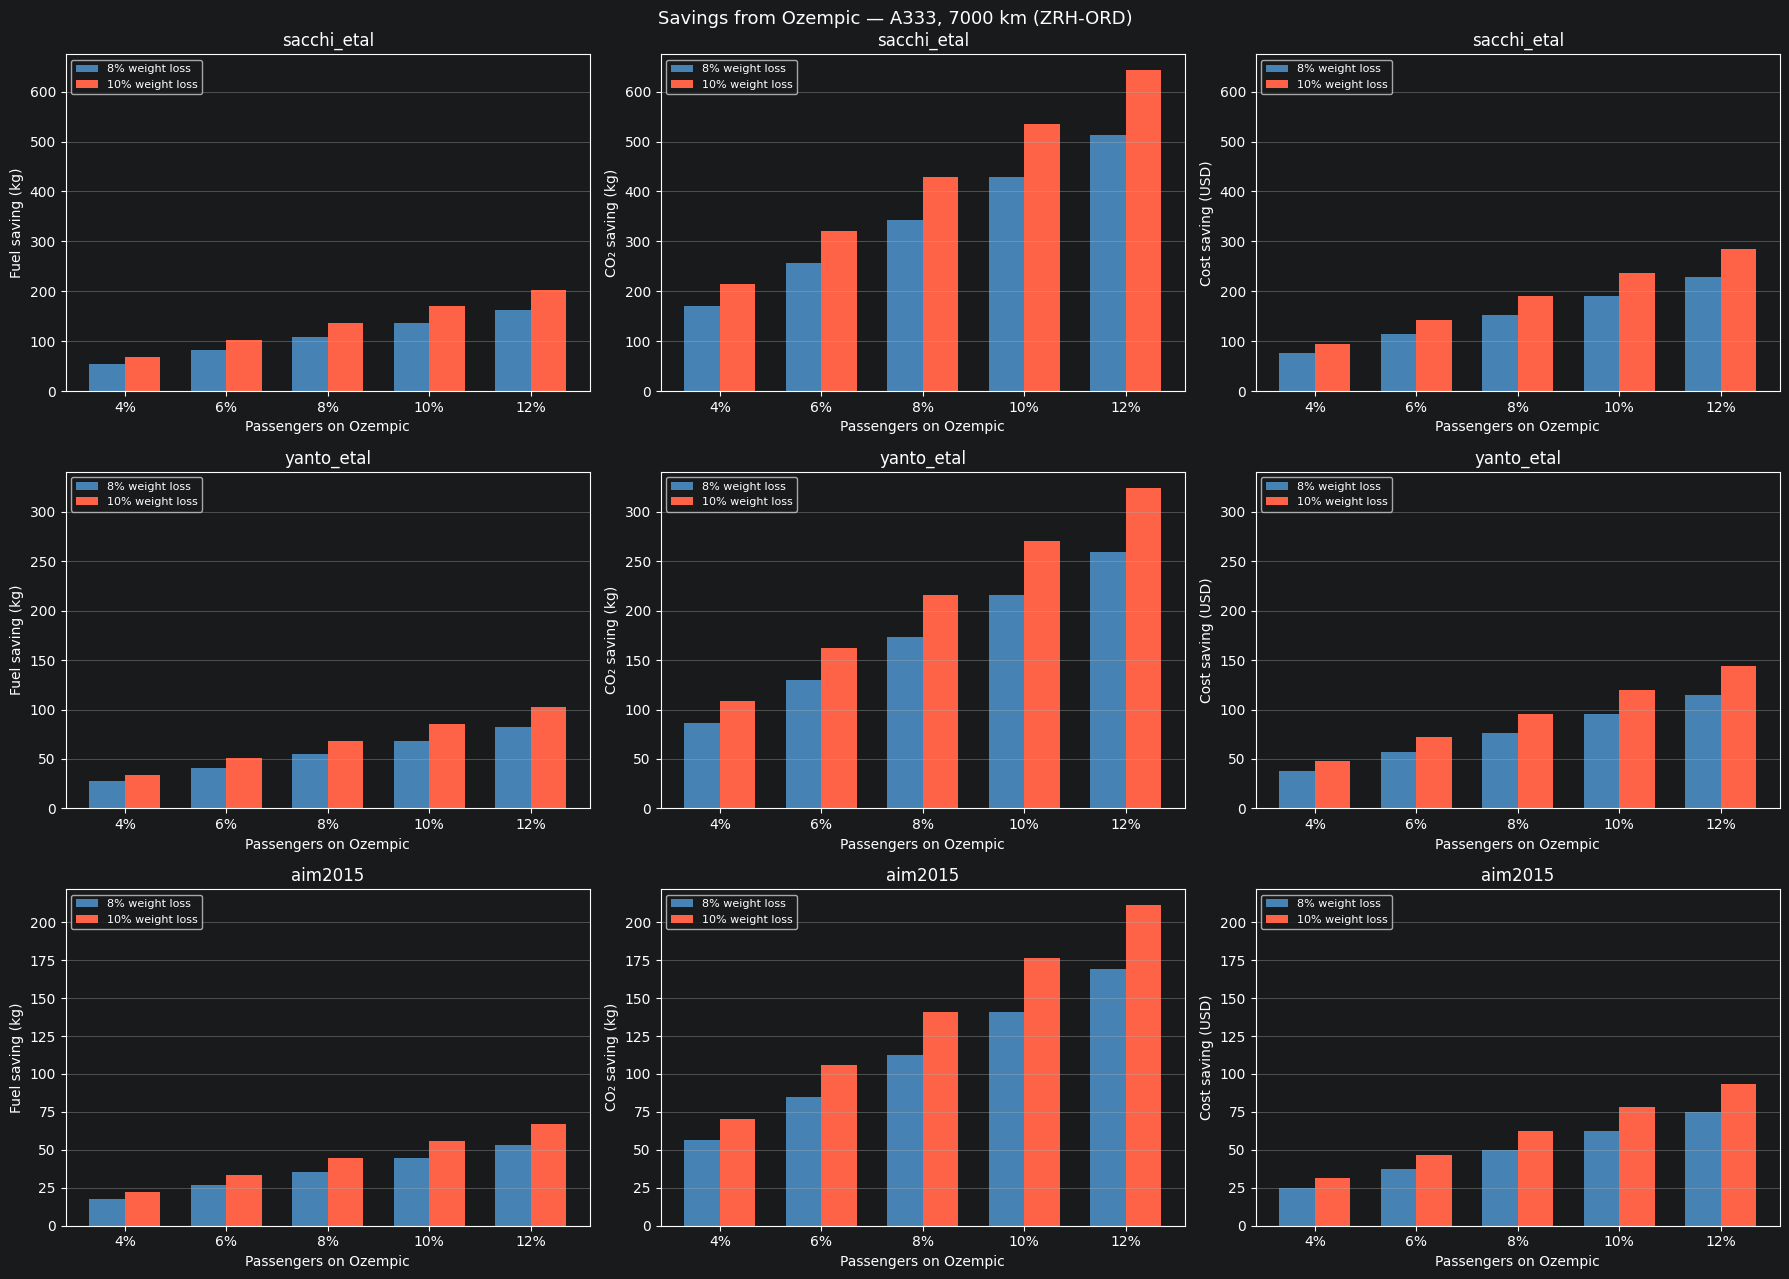

In [5]:
x = np.arange(len(ozempic_fractions))
width = 0.35
labels = [f"{int(oz * 100)}%" for oz in ozempic_fractions]
colors = ["steelblue", "tomato"]

fig, axes = plt.subplots(3, 3, figsize=(18, 13), sharey="row")
fig.suptitle("Savings from Ozempic — A333, 7000 km (ZRH-ORD)", fontsize=13)

metrics = [
    ("sacchi_etal", "sacchi_fuel_diff_kg", "sacchi_co2_diff_kg", "sacchi_cost_diff_usd"),
    ("yanto_etal",  "yanto_fuel_diff_kg",  "yanto_co2_diff_kg",  "yanto_cost_diff_usd"),
    ("aim2015",     "aim2015_fuel_diff_kg", "aim2015_co2_diff_kg", "aim2015_cost_diff_usd"),
]

for row_idx, (model, fuel_col, co2_col, cost_col) in enumerate(metrics):
    for col_idx, (metric, ylabel) in enumerate(
        [
            (fuel_col, "Fuel saving (kg)"),
            (co2_col, "CO₂ saving (kg)"),
            (cost_col, "Cost saving (USD)"),
        ]
    ):
        ax = axes[row_idx][col_idx]
        for i, wl in enumerate(weightloss_coeffs):
            subset = df[df["weightloss_coeff"] == wl].sort_values("people_on_ozempic")
            ax.bar(
                x + (i - 0.5) * width,
                subset[metric].values,
                width,
                label=f"{int(wl * 100)}% weight loss",
                color=colors[i],
            )
        ax.set_title(f"{model}")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Passengers on Ozempic")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.tick_params(labelleft=True)
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(axis="y", linewidth=0.5)

plt.tight_layout()
plt.savefig("savings_per_flight.pdf", bbox_inches="tight")
plt.show()

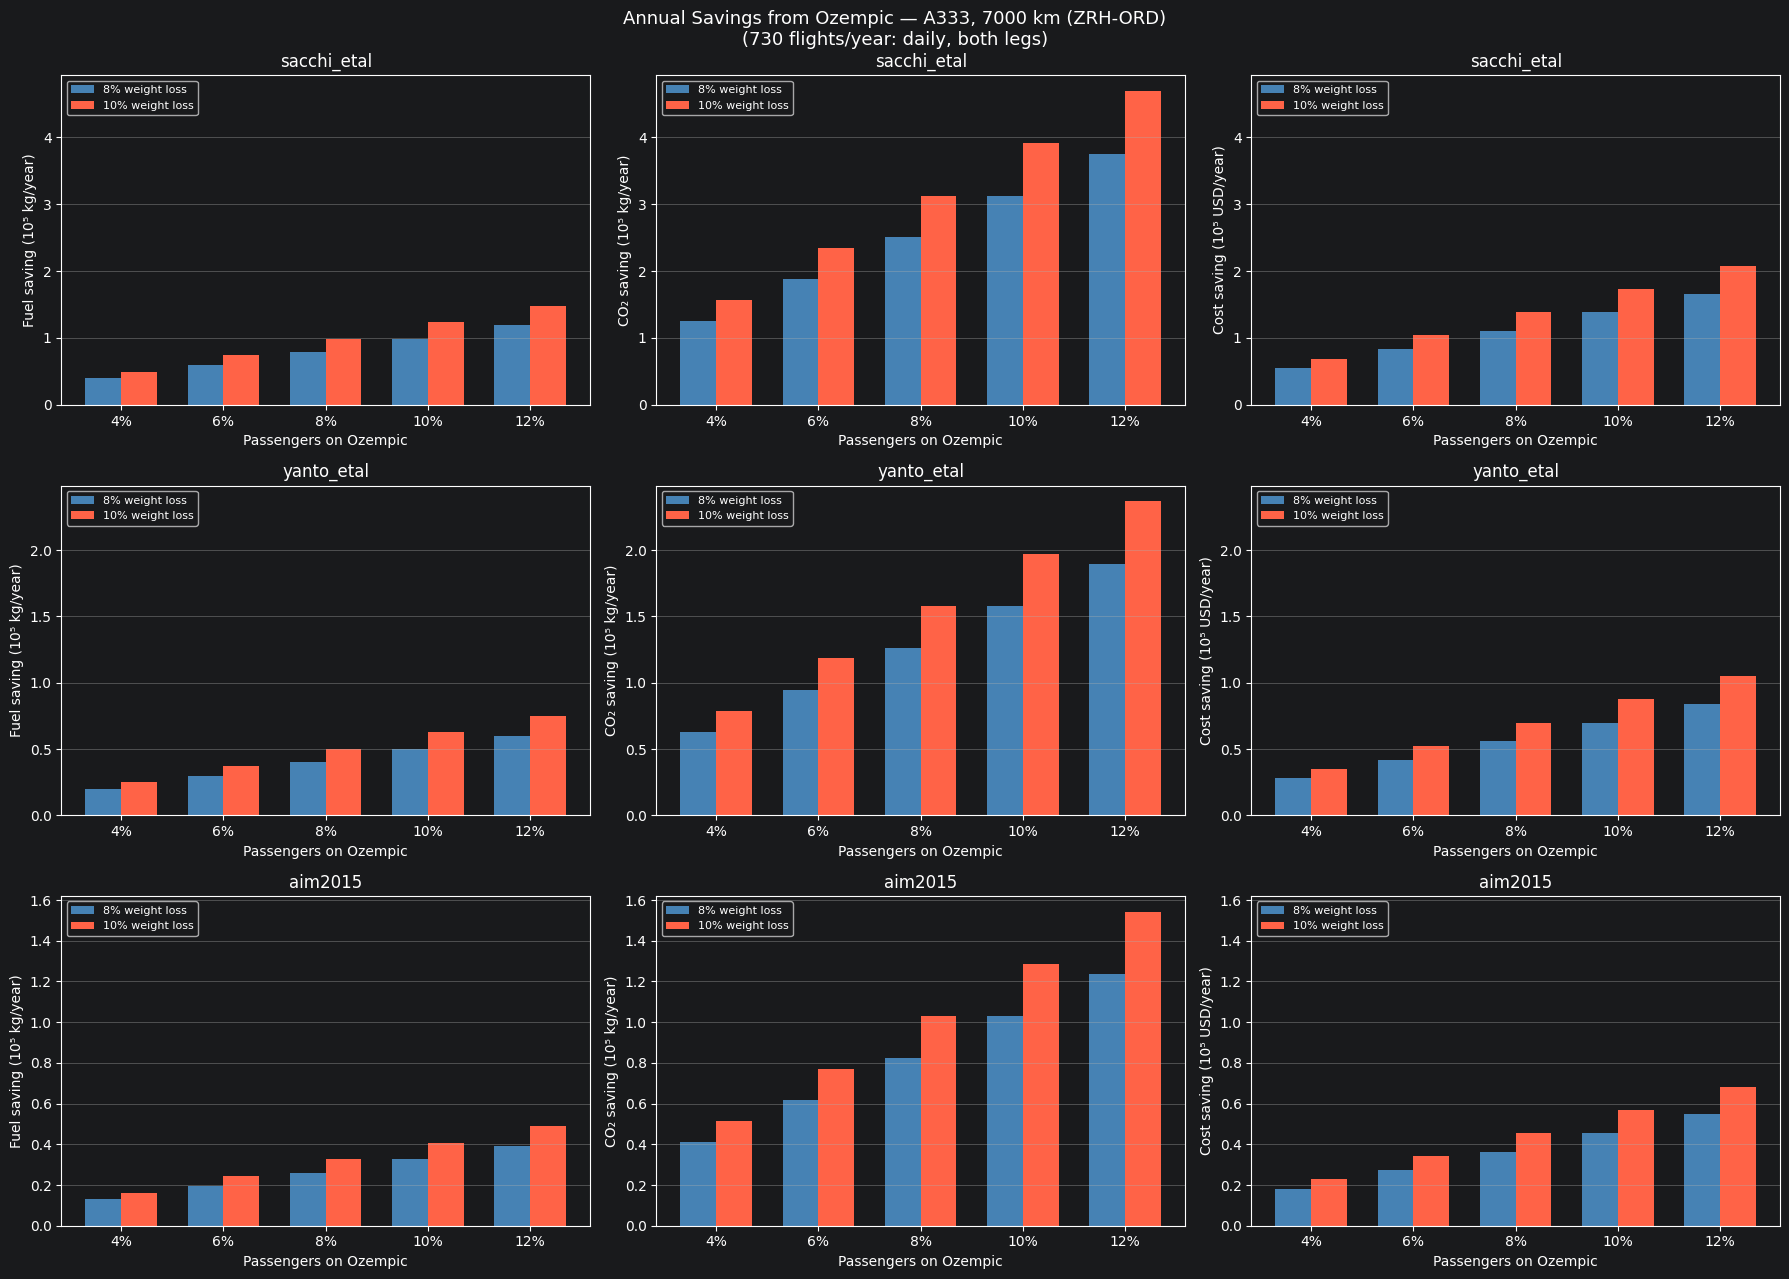

In [6]:
FLIGHTS_PER_YEAR = 2 * 365  # daily flight, both inbound and outbound legs
SCALE = 1e5

df_annual = df.copy()
for col in [
    "sacchi_fuel_diff_kg",
    "sacchi_co2_diff_kg",
    "sacchi_cost_diff_usd",
    "yanto_fuel_diff_kg",
    "yanto_co2_diff_kg",
    "yanto_cost_diff_usd",
    "aim2015_fuel_diff_kg",
    "aim2015_co2_diff_kg",
    "aim2015_cost_diff_usd",
]:
    df_annual[col] = df[col] * FLIGHTS_PER_YEAR / SCALE

fig, axes = plt.subplots(3, 3, figsize=(18, 13), sharey="row")
fig.suptitle(
    f"Annual Savings from Ozempic — A333, 7000 km (ZRH-ORD)\n"
    f"({FLIGHTS_PER_YEAR} flights/year: daily, both legs)",
    fontsize=13,
)

for row_idx, (model, fuel_col, co2_col, cost_col) in enumerate(metrics):
    for col_idx, (metric, ylabel) in enumerate(
        [
            (fuel_col, "Fuel saving (10⁵ kg/year)"),
            (co2_col, "CO₂ saving (10⁵ kg/year)"),
            (cost_col, "Cost saving (10⁵ USD/year)"),
        ]
    ):
        ax = axes[row_idx][col_idx]
        for i, wl in enumerate(weightloss_coeffs):
            subset = df_annual[df_annual["weightloss_coeff"] == wl].sort_values(
                "people_on_ozempic"
            )
            ax.bar(
                x + (i - 0.5) * width,
                subset[metric].values,
                width,
                label=f"{int(wl * 100)}% weight loss",
                color=colors[i],
            )
        ax.set_title(f"{model}")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Passengers on Ozempic")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.tick_params(labelleft=True)
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(axis="y", linewidth=0.5)

plt.tight_layout()
plt.savefig("savings_annual.pdf", bbox_inches="tight")
plt.show()

In [7]:
# fuel burn reduction through GLP-1 medication
import pandas as pd
from jetfuelburn.reducedorder import yanto_etal, sacchi_etal, aim2015
from jetfuelburn import ureg

CO2_FACTOR = 3.16       # kg CO2 per kg jet-A (IATA standard)
FUEL_COST_PER_KG = 1.4  # USD per kg (1400 USD per metric tonne)

# FAA AC 120-27F carry-on allowance (personal item + carry-on bag)
CARRYON_KG = 7.3 * ureg.kg

# Flight-weighted mean body weights
# (pre-GLP1 values, sex x age group)
body_weights = {
    ("male", "18-35"): 87.34 * ureg.kg,
    ("male", "35-50"): 89.88 * ureg.kg,
    ("male", "50-65"): 88.86 * ureg.kg,
    ("male", "65-80"): 84.39 * ureg.kg,
    ("female", "18-35"): 73.59 * ureg.kg,
    ("female", "35-50"): 77.01 * ureg.kg,
    ("female", "50-65"): 78.74 * ureg.kg,
    ("female", "65-80"): 71.26 * ureg.kg,
}

# Total pax weight = body weight + carry-on (FAA AC 120-27F method)
total_weights = {k: v + CARRYON_KG for k, v in body_weights.items()}

# Fleet-wide mean (equal weighting across sex x age strata)
mean_pax_weight = sum(total_weights.values()) / len(total_weights)
print(f"Fleet-wide mean pax weight (body + carry-on): {mean_pax_weight.to('kg'):.1f}")

# GLP-1 delta (body weight only, carry-on unaffected)
delta_kg_per_pax = 0.557 * ureg.kg

# Fleet segments
# AIM2015 size classes: 5=Large Narrowbody (B737-800 ref.), 7=Medium Twin Aisle (A330-300 ref.)
fleet_segments = [
    {
        "name": "domestic_narrowbody",
        "acft": "A320",
        "R": 1850 * ureg.km,
        "seats": 162,
        "aim2015_class": 5,
        "D_climb": 120 * ureg.km,
        "D_descent": 100 * ureg.km,
    },
    {
        "name": "transcon_narrowbody",
        "acft": "A321",
        "R": 4100 * ureg.km,
        "seats": 180,
        "aim2015_class": 5,
        "D_climb": 200 * ureg.km,
        "D_descent": 150 * ureg.km,
    },
    {
        "name": "international_widebody",
        "acft": "B772",
        "R": 9000 * ureg.km,
        "seats": 280,
        "aim2015_class": 7,
        "D_climb": 300 * ureg.km,
        "D_descent": 200 * ureg.km,
    },
]

# Sacchi models weight reduction as an equivalent fractional pax reduction
weight_reduction_fraction = (delta_kg_per_pax / mean_pax_weight).magnitude

records = []
for seg in fleet_segments:
    payload_base = seg["seats"] * mean_pax_weight
    payload_glp1 = payload_base - (seg["seats"] * delta_kg_per_pax)
    D_cruise_seg = seg["R"] - seg["D_climb"] - seg["D_descent"]

    # yanto_etal: uses absolute payload
    fuel_yanto_base = yanto_etal.calculate_fuel_consumption(
        acft=seg["acft"],
        R=seg["R"],
        PL=payload_base,
    )
    fuel_yanto_glp1 = yanto_etal.calculate_fuel_consumption(
        acft=seg["acft"],
        R=seg["R"],
        PL=payload_glp1,
    )
    yanto_fuel_delta = (fuel_yanto_base - fuel_yanto_glp1).to("kg").magnitude
    yanto_co2_delta = yanto_fuel_delta * CO2_FACTOR
    yanto_cost_delta = yanto_fuel_delta * FUEL_COST_PER_KG

    # sacchi_etal: weight reduction expressed as equivalent reduction in pax count
    pax_base = seg["seats"]
    pax_glp1 = pax_base * (1 - weight_reduction_fraction)
    fuel_sacchi_base = sacchi_etal.calculate_fuel_consumption(
        year=2024,
        pax_max=seg["seats"],
        pax=pax_base,
        R=seg["R"],
    )
    fuel_sacchi_glp1 = sacchi_etal.calculate_fuel_consumption(
        year=2024,
        pax_max=seg["seats"],
        pax=pax_glp1,
        R=seg["R"],
    )
    sacchi_fuel_delta = (fuel_sacchi_base - fuel_sacchi_glp1).to("kg").magnitude
    sacchi_co2_delta = sacchi_fuel_delta * CO2_FACTOR
    sacchi_cost_delta = sacchi_fuel_delta * FUEL_COST_PER_KG

    # aim2015: uses absolute payload
    _aim2015_base = aim2015.calculate_fuel_consumption(
        acft_size_class=seg["aim2015_class"],
        D_climb=seg["D_climb"],
        D_cruise=D_cruise_seg,
        D_descent=seg["D_descent"],
        PL=payload_base,
    )
    _aim2015_glp1 = aim2015.calculate_fuel_consumption(
        acft_size_class=seg["aim2015_class"],
        D_climb=seg["D_climb"],
        D_cruise=D_cruise_seg,
        D_descent=seg["D_descent"],
        PL=payload_glp1,
    )
    aim2015_fuel_delta = (sum(_aim2015_base.values()) - sum(_aim2015_glp1.values())).to("kg").magnitude
    aim2015_co2_delta = aim2015_fuel_delta * CO2_FACTOR
    aim2015_cost_delta = aim2015_fuel_delta * FUEL_COST_PER_KG

    records.append(
        {
            "segment": seg["name"],
            "aircraft": seg["acft"],
            "distance_km": seg["R"].magnitude,
            "seats": seg["seats"],
            "mean_pax_kg": round(mean_pax_weight.magnitude, 1),
            "yanto_fuel_base_kg": round(fuel_yanto_base.to("kg").magnitude, 1),
            "yanto_fuel_delta_kg": round(yanto_fuel_delta, 2),
            "yanto_co2_delta_kg": round(yanto_co2_delta, 2),
            "yanto_cost_delta_usd": round(yanto_cost_delta, 2),
            "sacchi_fuel_base_kg": round(fuel_sacchi_base.to("kg").magnitude, 1),
            "sacchi_fuel_delta_kg": round(sacchi_fuel_delta, 2),
            "sacchi_co2_delta_kg": round(sacchi_co2_delta, 2),
            "sacchi_cost_delta_usd": round(sacchi_cost_delta, 2),
            "aim2015_fuel_base_kg": round(sum(_aim2015_base.values()).to("kg").magnitude, 1),
            "aim2015_fuel_delta_kg": round(aim2015_fuel_delta, 2),
            "aim2015_co2_delta_kg": round(aim2015_co2_delta, 2),
            "aim2015_cost_delta_usd": round(aim2015_cost_delta, 2),
        }
    )

df_step3 = pd.DataFrame(records)
print(df_step3.to_string(index=False))

Fleet-wide mean pax weight (body + carry-on): 88.7 kilogram
               segment aircraft  distance_km  seats  mean_pax_kg  yanto_fuel_base_kg  yanto_fuel_delta_kg  yanto_co2_delta_kg  yanto_cost_delta_usd  sacchi_fuel_base_kg  sacchi_fuel_delta_kg  sacchi_co2_delta_kg  sacchi_cost_delta_usd  aim2015_fuel_base_kg  aim2015_fuel_delta_kg  aim2015_co2_delta_kg  aim2015_cost_delta_usd
   domestic_narrowbody     A320         1850    162         88.7              6044.0                12.45               39.35                 17.43               9849.6                 13.82                43.66                  19.34                5001.6                   5.92                 18.71                    8.29
   transcon_narrowbody     A321         4100    180         88.7             14391.0                17.65               55.76                 24.70              21131.9                 30.03                94.91                  42.05               11633.2                  15.94         

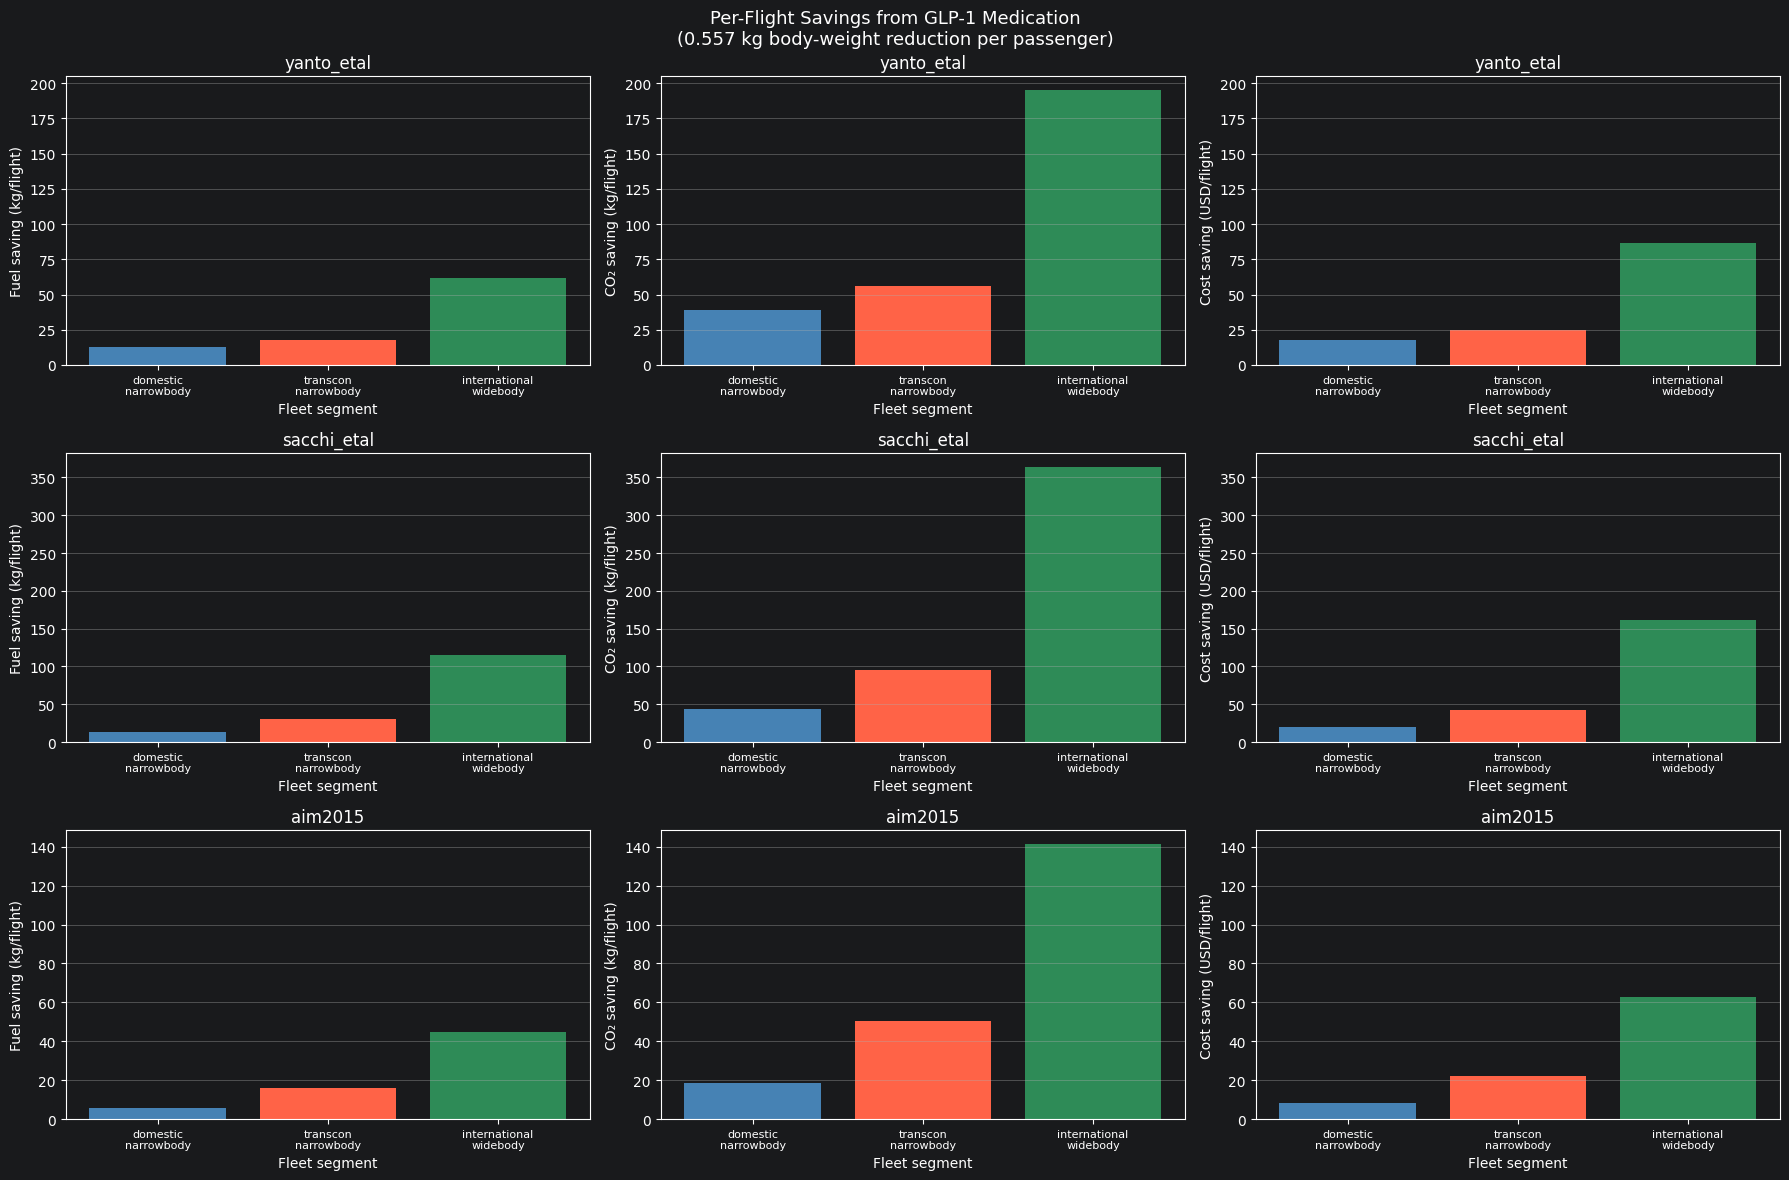

In [8]:
segment_labels = [s.replace("_", "\n") for s in df_step3["segment"]]
x3 = np.arange(len(df_step3))
colors3 = ["steelblue", "tomato", "seagreen"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharey="row")
fig.suptitle(
    "Per-Flight Savings from GLP-1 Medication\n(0.557 kg body-weight reduction per passenger)",
    fontsize=13,
)

metrics3 = [
    ("yanto_etal",  "yanto_fuel_delta_kg",  "yanto_co2_delta_kg",  "yanto_cost_delta_usd"),
    ("sacchi_etal", "sacchi_fuel_delta_kg", "sacchi_co2_delta_kg", "sacchi_cost_delta_usd"),
    ("aim2015",     "aim2015_fuel_delta_kg", "aim2015_co2_delta_kg", "aim2015_cost_delta_usd"),
]

for row_idx, (model, fuel_col, co2_col, cost_col) in enumerate(metrics3):
    for col_idx, (metric, ylabel) in enumerate(
        [
            (fuel_col, "Fuel saving (kg/flight)"),
            (co2_col, "CO₂ saving (kg/flight)"),
            (cost_col, "Cost saving (USD/flight)"),
        ]
    ):
        ax = axes[row_idx][col_idx]
        ax.bar(x3, df_step3[metric].values, color=colors3[: len(df_step3)])
        ax.set_title(model)
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Fleet segment")
        ax.set_xticks(x3)
        ax.set_xticklabels(segment_labels, fontsize=8)
        ax.tick_params(labelleft=True)
        ax.grid(axis="y", linewidth=0.5)

plt.tight_layout()
plt.savefig("savings_per_flight_glp1.pdf", bbox_inches="tight")
plt.show()

In [9]:
# Annual departures by segment (BTS T-100 / FAA 2023)
annual_departures = {
    "domestic_narrowbody":    7_200_000,
    "transcon_narrowbody":      800_000,
    "international_widebody":   400_000,
}

TONNES_PER_KG = 1 / 1000
US_AVIATION_CO2_TONNES = 76_000_000  # ICCT 2022 baseline
FUEL_COST_PER_TONNE = 1_400          # USD per tonne of jet fuel

records_step4 = []
for _, row in df_step3.iterrows():
    n_flights = annual_departures[row["segment"]]
    sacchi_fuel_t  = row["sacchi_fuel_delta_kg"]  * n_flights * TONNES_PER_KG
    yanto_fuel_t   = row["yanto_fuel_delta_kg"]   * n_flights * TONNES_PER_KG
    aim2015_fuel_t = row["aim2015_fuel_delta_kg"] * n_flights * TONNES_PER_KG
    sacchi_co2_t   = row["sacchi_co2_delta_kg"]   * n_flights * TONNES_PER_KG
    yanto_co2_t    = row["yanto_co2_delta_kg"]    * n_flights * TONNES_PER_KG
    aim2015_co2_t  = row["aim2015_co2_delta_kg"]  * n_flights * TONNES_PER_KG
    records_step4.append({
        "segment":                 row["segment"],
        "annual_departures":       n_flights,
        "sacchi_fuel_annual_t":    round(sacchi_fuel_t, 0),
        "sacchi_cost_annual_usd":  round(sacchi_fuel_t  * FUEL_COST_PER_TONNE, 0),
        "sacchi_co2_annual_t":     round(sacchi_co2_t,  0),
        "sacchi_pct_us_aviation":  round(100 * sacchi_co2_t  / US_AVIATION_CO2_TONNES, 3),
        "yanto_fuel_annual_t":     round(yanto_fuel_t,  0),
        "yanto_cost_annual_usd":   round(yanto_fuel_t   * FUEL_COST_PER_TONNE, 0),
        "yanto_co2_annual_t":      round(yanto_co2_t,   0),
        "yanto_pct_us_aviation":   round(100 * yanto_co2_t   / US_AVIATION_CO2_TONNES, 3),
        "aim2015_fuel_annual_t":   round(aim2015_fuel_t, 0),
        "aim2015_cost_annual_usd": round(aim2015_fuel_t * FUEL_COST_PER_TONNE, 0),
        "aim2015_co2_annual_t":    round(aim2015_co2_t,  0),
        "aim2015_pct_us_aviation": round(100 * aim2015_co2_t / US_AVIATION_CO2_TONNES, 3),
    })

df_step4 = pd.DataFrame(records_step4)

# Add total row
totals = {col: df_step4[col].sum() for col in df_step4.columns if col not in ("segment",)}
totals["segment"] = "TOTAL"
df_step4.loc[len(df_step4)] = totals

print("\nStep 4 — Annual fleet savings (all models):")
print(df_step4.to_string(index=False))


Step 4 — Annual fleet savings (all models):
               segment  annual_departures  sacchi_fuel_annual_t  sacchi_cost_annual_usd  sacchi_co2_annual_t  sacchi_pct_us_aviation  yanto_fuel_annual_t  yanto_cost_annual_usd  yanto_co2_annual_t  yanto_pct_us_aviation  aim2015_fuel_annual_t  aim2015_cost_annual_usd  aim2015_co2_annual_t  aim2015_pct_us_aviation
   domestic_narrowbody            7200000               99504.0             139305600.0             314352.0                   0.414              89640.0            125496000.0            283320.0                  0.373                42624.0               59673600.0              134712.0                    0.177
   transcon_narrowbody             800000               24024.0              33633600.0              75928.0                   0.100              14120.0             19768000.0             44608.0                  0.059                12752.0               17852800.0               40296.0                    0.053
internatio

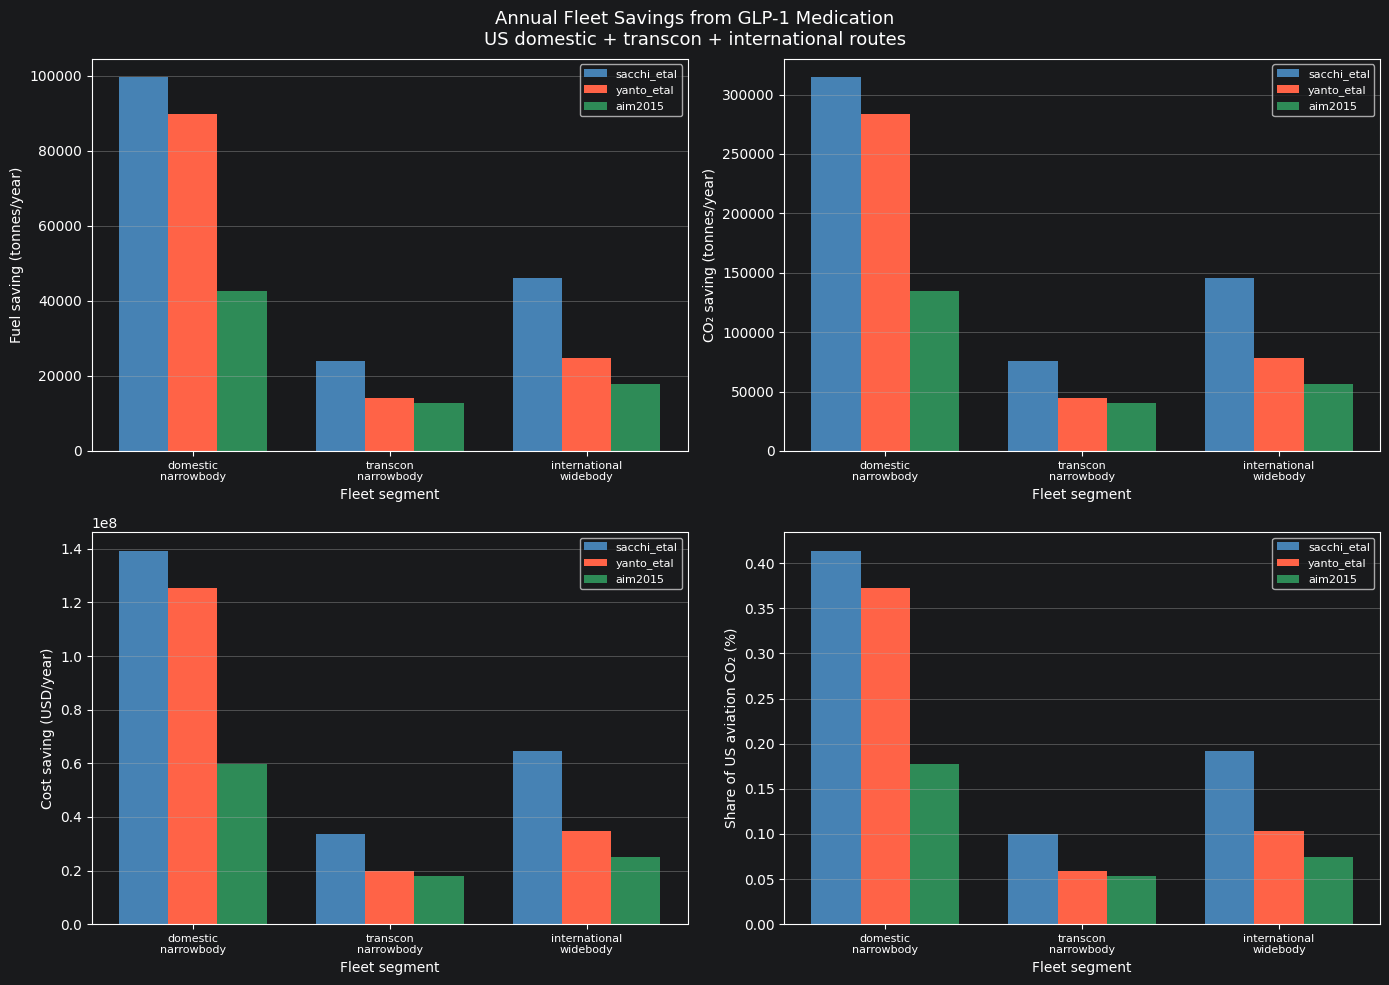

In [10]:
df_plot4 = df_step4[df_step4["segment"] != "TOTAL"].copy()
seg_labels4 = [s.replace("_", "\n") for s in df_plot4["segment"]]
x4 = np.arange(len(df_plot4))
width4 = 0.25
model_colors = ["steelblue", "tomato", "seagreen"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Annual Fleet Savings from GLP-1 Medication\n"
    "US domestic + transcon + international routes",
    fontsize=13,
)

panels = [
    ("sacchi_fuel_annual_t",   "yanto_fuel_annual_t",   "aim2015_fuel_annual_t",   "Fuel saving (tonnes/year)"),
    ("sacchi_co2_annual_t",    "yanto_co2_annual_t",    "aim2015_co2_annual_t",    "CO₂ saving (tonnes/year)"),
    ("sacchi_cost_annual_usd", "yanto_cost_annual_usd", "aim2015_cost_annual_usd", "Cost saving (USD/year)"),
    ("sacchi_pct_us_aviation", "yanto_pct_us_aviation", "aim2015_pct_us_aviation", "Share of US aviation CO₂ (%)"),
]

for ax, (col_sacchi, col_yanto, col_aim2015, ylabel) in zip(axes.flat, panels):
    ax.bar(x4 - width4, df_plot4[col_sacchi].values,  width4, label="sacchi_etal", color=model_colors[0])
    ax.bar(x4,          df_plot4[col_yanto].values,   width4, label="yanto_etal",  color=model_colors[1])
    ax.bar(x4 + width4, df_plot4[col_aim2015].values, width4, label="aim2015",     color=model_colors[2])
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Fleet segment")
    ax.set_xticks(x4)
    ax.set_xticklabels(seg_labels4, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis="y", linewidth=0.5)

plt.tight_layout()
plt.savefig("savings_fleet_co2_glp1.pdf", bbox_inches="tight")
plt.show()